In [1]:
# ============================================================
# Lab5: MLP 회귀 실습
# ============================================================
# 고전 신경망 MLP를 이용한 회귀 문제 학습.
# 두 입력 변수(x1, x2)로부터 y = x1 * x2 관계를 학습하는
# 간단한 다층 퍼셉트론 모델을 구현한다.
# 학습 과정에서 loss 감소와 예측 결과를 시각화하여
# 신경망의 함수 근사 능력과 일반화 성능을 확인한다.
# 실습 목표
#
# 1. 고전 신경망(MLP)을 사용한 회귀 문제를 이해한다.
# 2. 입력 데이터를 스케일링하여 학습 안정성을 높인다.
# 3. train/test 분할을 통해 일반화 성능을 평가한다.
# 4. 학습 과정(loss 감소)을 시각적으로 확인한다.
# 5. 예측 결과와 실제 값을 비교하여 모델 성능을 평가한다.

In [2]:
# ============================================================
# 설치 (Colab용)
# ============================================================

# !pip install pennylane koreanize_matplotlib -q

In [3]:
# ============================================================
# 라이브러리
# ============================================================

import torch
import torch.nn as nn
import numpy as std_np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from IPython.display import clear_output

plt.rcParams['axes.unicode_minus'] = False

In [4]:
# ============================================================
# 수정 영역
# ============================================================

epochs = 100
lr = 0.01

# 추천
# lr = 0.001  → 느리지만 안정
# lr = 0.01   → 기본
# lr = 0.1    → 빠르지만 불안정

In [5]:
# ============================================================
# 데이터 생성
# ============================================================

x1 = std_np.array([2*i + 1 for i in range(50)], dtype=float)
x2 = std_np.array([2*(i + 1) for i in range(50)], dtype=float)

y = x1 * x2

THEORY_SUM = 169150

print("--- 데이터 확인 ---")
print(f"x1[:5] = {x1[:5]}")
print(f"x2[:5] = {x2[:5]}")
print(f"y[:5]  = {y[:5]}")
print(f"y 범위: {y.min():.0f} ~ {y.max():.0f}")
print(f"이론 총합 = {y.sum():.0f}")

--- 데이터 확인 ---
x1[:5] = [1. 3. 5. 7. 9.]
x2[:5] = [ 2.  4.  6.  8. 10.]
y[:5]  = [ 2. 12. 30. 56. 90.]
y 범위: 2 ~ 9900
이론 총합 = 169150


In [6]:
# ============================================================
# 스케일링
# ============================================================

def scale_x(x):
    return (x - 1) / 99 * std_np.pi


Y_MIN = 2.0
Y_MAX = 9900.0


def scale_y(y_val):
    return (y_val - Y_MIN) / (Y_MAX - Y_MIN)


def unscale_y(y_scaled):
    return y_scaled * (Y_MAX - Y_MIN) + Y_MIN


x1_sc = scale_x(x1)
x2_sc = scale_x(x2)

y_sc = scale_y(y)

In [7]:
# ============================================================
# train / test 분할
# ============================================================

std_np.random.seed(42)

idx = std_np.random.permutation(50)

n_train = 35

idx_train = idx[:n_train]
idx_test = idx[n_train:]

print(f"\ntrain: {n_train}개")
print(f"test : {len(idx_test)}개")


train: 35개
test : 15개


In [8]:
# ============================================================
# Lab5: MLP 회귀
# ============================================================

print("\n" + "=" * 60)
print("lab5: MLP (고전 신경망 회귀)")
print("=" * 60)


class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2, 3),
            nn.Tanh(),

            nn.Linear(3, 1),
            nn.Sigmoid()   # 출력 [0,1]

        )

    def forward(self, x):

        return self.net(x).squeeze()


lab5: MLP (고전 신경망 회귀)


In [9]:
# ============================================================
# Tensor 변환
# ============================================================

X_train_t = torch.tensor(
    std_np.column_stack([x1_sc[idx_train], x2_sc[idx_train]]),
    dtype=torch.float32
)

y_train_t = torch.tensor(
    y_sc[idx_train],
    dtype=torch.float32
)

X_all_t = torch.tensor(
    std_np.column_stack([x1_sc, x2_sc]),
    dtype=torch.float32
)

In [10]:
# ============================================================
# 모델 생성
# ============================================================

torch.manual_seed(42)

model = MLP()

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

criterion = nn.MSELoss()

n_params = sum(p.numel() for p in model.parameters())

print(f"MLP 구조: 2 → 3 → 1")
print(f"활성함수: Tanh + Sigmoid")
print(f"파라미터 수: {n_params}")
print(f"epochs={epochs}, lr={lr}")

MLP 구조: 2 → 3 → 1
활성함수: Tanh + Sigmoid
파라미터 수: 13
epochs=100, lr=0.01


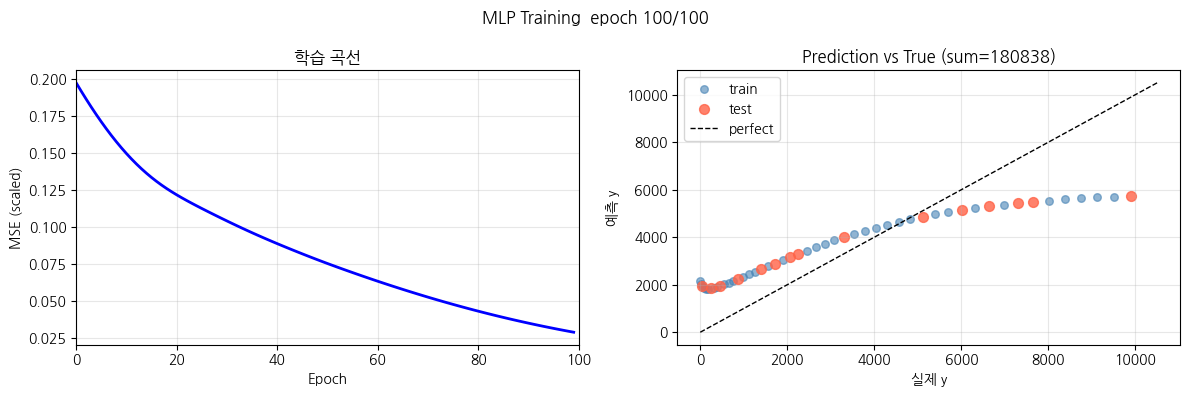

In [11]:
# ============================================================
# 학습
# ============================================================

mlp_history = []

for ep in range(epochs):

    optimizer.zero_grad()

    pred = model(X_train_t)

    loss = criterion(pred, y_train_t)

    loss.backward()

    optimizer.step()

    mlp_history.append(loss.item())

    if ep % 5 == 0 or ep == epochs - 1:

        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        fig.suptitle(f"MLP Training  epoch {ep+1}/{epochs}")

        # 학습 곡선
        ax1.plot(mlp_history, 'b-', lw=2)

        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("MSE (scaled)")
        ax1.set_title("학습 곡선")

        ax1.set_xlim(0, epochs)

        ax1.grid(True, alpha=0.3)

        # 예측 vs 실제
        with torch.no_grad():

            preds_sc = model(X_all_t).numpy()

        preds_now = unscale_y(preds_sc)

        ax2.scatter(
            y[idx_train],
            preds_now[idx_train],
            c='steelblue',
            alpha=0.6,
            s=30,
            label='train'
        )

        ax2.scatter(
            y[idx_test],
            preds_now[idx_test],
            c='tomato',
            alpha=0.8,
            s=50,
            label='test'
        )

        ax2.plot(
            [0, 10500],
            [0, 10500],
            'k--',
            lw=1,
            label='perfect'
        )

        ax2.set_xlabel("실제 y")
        ax2.set_ylabel("예측 y")

        ax2.set_title(
            f"Prediction vs True (sum={preds_now.sum():.0f})"
        )

        ax2.legend()

        ax2.grid(True, alpha=0.3)

        plt.tight_layout()

        plt.show()

In [12]:
# ============================================================
# 최종 예측
# ============================================================

with torch.no_grad():

    mlp_preds_sc = model(X_all_t).numpy()

mlp_preds = unscale_y(mlp_preds_sc)

mlp_sum = mlp_preds.sum()

mlp_test_mse = std_np.mean(
    (mlp_preds[idx_test] - y[idx_test]) ** 2
)

print("\n결과")

print(f"MLP 총합: {mlp_sum:.1f}")
print(f"이론 총합: {THEORY_SUM}")

print(f"test MSE: {mlp_test_mse:.2f}")

print("\nlab5 완료!")


결과
MLP 총합: 180838.0
이론 총합: 169150
test MSE: 2942343.88

lab5 완료!


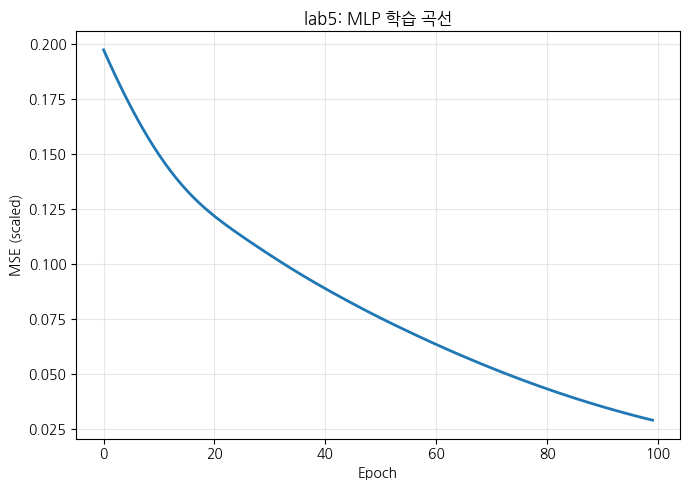

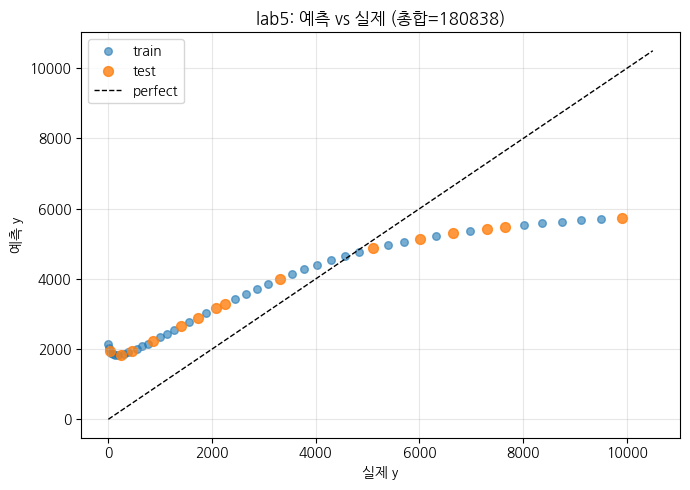

In [13]:
# ============================================================
# 그래프 저장
# ============================================================

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(mlp_history, lw=2)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.set_title("lab5: MLP 학습 곡선")

ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig("./lab5a.png", dpi=300)

plt.show()


fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(
    y[idx_train],
    mlp_preds[idx_train],
    alpha=0.6,
    s=30,
    label='train'
)

ax.scatter(
    y[idx_test],
    mlp_preds[idx_test],
    alpha=0.8,
    s=50,
    label='test'
)

ax.plot(
    [0, 10500],
    [0, 10500],
    'k--',
    lw=1,
    label='perfect'
)

ax.set_xlabel("실제 y")
ax.set_ylabel("예측 y")

ax.set_title(f"lab5: 예측 vs 실제 (총합={mlp_sum:.0f})")

ax.legend()

ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig("./lab5b.png", dpi=300)

plt.show()